# Local Training Data Analysis Notebook

This notebook analyzes local training data from topology experiments and generates:
1. **Multi-Seed Figure6 Plots** - Aggregated performance with confidence intervals
2. **Learning Speed Analysis** - Derivative-based learning rate comparison
3. **Cumulative Reward Table** - Topology performance comparison

## Data Source
All data is loaded from local `test_experiments/` folders generated during training runs.

In [43]:
# Import required libraries
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## Utility Functions

Common functions used across all analysis sections.

In [44]:
def load_training_data(base_path: str = "cartpole/N0002/S256/") -> Dict:
    """
    Load all training data from local folders.
    
    Args:
        base_path: Path to test_experiments directory
        
    Returns:
        Dictionary with topology groups and their data
    """
    
    if not os.path.exists(base_path):
        print(f"❌ Directory {base_path} not found")
        return {}
    
    topology_groups = {}
    
    # Scan all directories
    for item in os.listdir(base_path):
        item_path = os.path.join(base_path, item)
        if not os.path.isdir(item_path):
            continue
            
        # Try to load metadata
        metadata_file = os.path.join(item_path, "run_metadata.json")
        if not os.path.exists(metadata_file):
            continue
            
        try:
            with open(metadata_file, 'r') as f:
                metadata = json.load(f)
            
            # Extract topology type and seed
            if 'training_config' in metadata:
                config = metadata['training_config']
                topology_type = config.get('topology_type', 'unknown')
                seed = config.get('seed', 'unknown')
                task_name = config.get('task_name', 'unknown')
                
                # Create topology group key (excluding seed)
                topology_key = f"{task_name}_{topology_type}"
                
                if topology_key not in topology_groups:
                    topology_groups[topology_key] = {
                        'runs': [],
                        'task_name': task_name,
                        'topology_type': topology_type,
                        'metadata': metadata
                    }
                
                # Load episode data
                episode_file = os.path.join(item_path, "data", "episode_data.csv")
                if os.path.exists(episode_file):
                    episode_data = pd.read_csv(episode_file)
                    
                    topology_groups[topology_key]['runs'].append({
                        'seed': seed,
                        'folder': item,
                        'episode_data': episode_data,
                        'metadata': metadata
                    })
                    
        except Exception as e:
            print(f"⚠️  Error loading {item}: {e}")
            continue
    
    # Sort runs by seed for each topology
    for topology_key in topology_groups:
        topology_groups[topology_key]['runs'].sort(key=lambda x: x['seed'])
    
    print(f"✅ Loaded data for {len(topology_groups)} topology types:")
    for topology_key, group in topology_groups.items():
        print(f"   📊 {topology_key}: {len(group['runs'])} seeds")
    
    return topology_groups

def apply_window_smoothing(data: np.ndarray, window: int = 5) -> np.ndarray:
    """
    Apply window smoothing to data (like in main.ipynb).
    
    Args:
        data: Input data array
        window: Window size for smoothing
        
    Returns:
        Smoothed data array
    """
    if len(data) < window:
        return data
    
    smoothed = np.convolve(data, np.ones(window)/window, mode='valid')
    # Pad the beginning to maintain array length
    padding = np.full(window-1, smoothed[0])
    return np.concatenate([padding, smoothed])

def calculate_confidence_intervals(data_arrays: List[np.ndarray], confidence: float = 0.95) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Calculate mean and confidence intervals across multiple arrays.
    
    Args:
        data_arrays: List of numpy arrays
        confidence: Confidence level (0.95 for 95%)
        
    Returns:
        (mean, lower_bound, upper_bound)
    """
    if not data_arrays:
        return np.array([]), np.array([]), np.array([])
    
    # Stack arrays and calculate statistics
    stacked = np.vstack(data_arrays)
    mean = np.mean(stacked, axis=0)
    std = np.std(stacked, axis=0)
    
    # Calculate confidence intervals (assuming normal distribution)
    n = len(data_arrays)
    if n > 1:
        # t-distribution for small samples
        from scipy import stats
        t_value = stats.t.ppf((1 + confidence) / 2, n - 1)
        margin = t_value * std / np.sqrt(n)
    else:
        margin = np.zeros_like(std)
    
    lower_bound = mean - margin
    upper_bound = mean + margin
    
    return mean, lower_bound, upper_bound

print("✅ Utility functions defined")

✅ Utility functions defined


## Section 1: Multi-Seed Figure6 Aggregation

Aggregate performance data across multiple seeds for each topology type, applying window=5 smoothing and calculating confidence intervals.

In [45]:
# Load training data
print("🔄 Loading training data...")
topology_groups = load_training_data()

if not topology_groups:
    print("❌ No training data found. Please run some training experiments first.")
else:
    print(f"✅ Loaded {len(topology_groups)} topology groups")

🔄 Loading training data...
✅ Loaded data for 5 topology types:
   📊 CartPole-v1_fully_connected: 6 seeds
   📊 CartPole-v1_small_world: 6 seeds
   📊 CartPole-v1_standard_mlp: 6 seeds
   📊 CartPole-v1_hybrid: 6 seeds
   📊 CartPole-v1_modular: 6 seeds
✅ Loaded 5 topology groups


In [46]:
def prepare_figure6_data(topology_groups: Dict) -> Dict:
    """
    Prepare data for Figure6-style plots with multi-seed aggregation.
    """
    figure6_data = {}
    
    for topology_key, group in topology_groups.items():
        if len(group['runs']) < 2:
            print(f"⚠️  Skipping {topology_key}: Need at least 2 seeds for aggregation")
            continue
        
        # Extract episode rewards for each seed
        seed_rewards = []
        max_episodes = 0
        
        for run in group['runs']:
            episode_data = run['episode_data']
            if 'episode_return_raw' in episode_data.columns:
                rewards = episode_data['episode_return_raw'].values
                seed_rewards.append(rewards)
                max_episodes = max(max_episodes, len(rewards))
            else:
                print(f"⚠️  No episode_return_raw column in {run['folder']}")
        
        if not seed_rewards:
            continue
        
        # Pad arrays to same length and apply smoothing
        padded_rewards = []
        for rewards in seed_rewards:
            if len(rewards) < max_episodes:
                # Pad with last value
                padded = np.pad(rewards, (0, max_episodes - len(rewards)), 
                               mode='edge')
            else:
                padded = rewards[:max_episodes]
            
            # Apply window=5 smoothing
            smoothed = apply_window_smoothing(padded, window=10)
            padded_rewards.append(smoothed)
        
        # Calculate confidence intervals
        mean_rewards, lower_bound, upper_bound = calculate_confidence_intervals(padded_rewards)
        
        figure6_data[topology_key] = {
            'episodes': np.arange(1, max_episodes + 1),
            'mean_rewards': mean_rewards,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'num_seeds': len(padded_rewards),
            'topology_type': group['topology_type'],
            'task_name': group['task_name']
        }
    
    return figure6_data

# Prepare Figure6 data
print("🔄 Preparing Figure6 data...")
figure6_data = prepare_figure6_data(topology_groups)
print(f"✅ Prepared data for {len(figure6_data)} topology types")

🔄 Preparing Figure6 data...
✅ Prepared data for 5 topology types


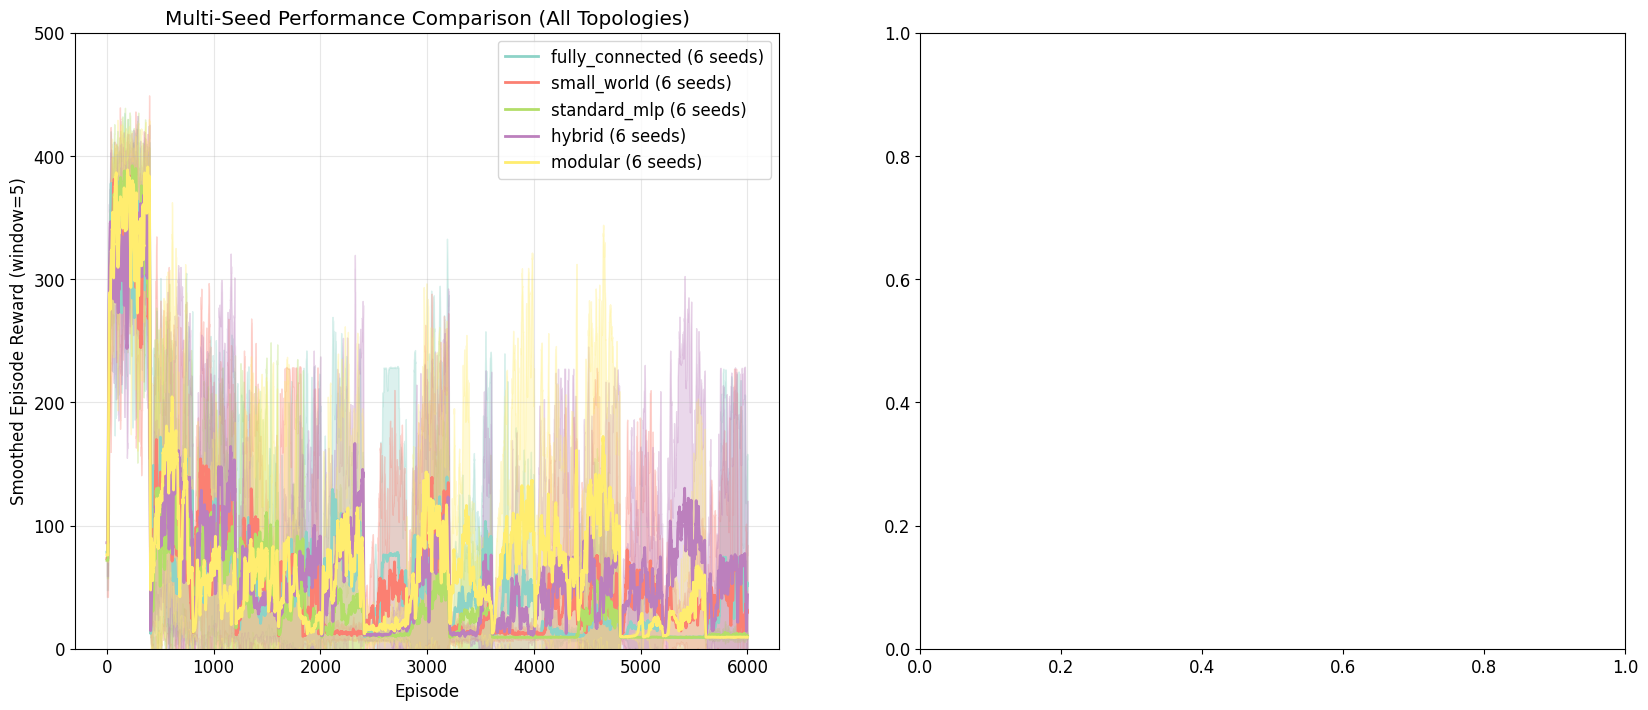

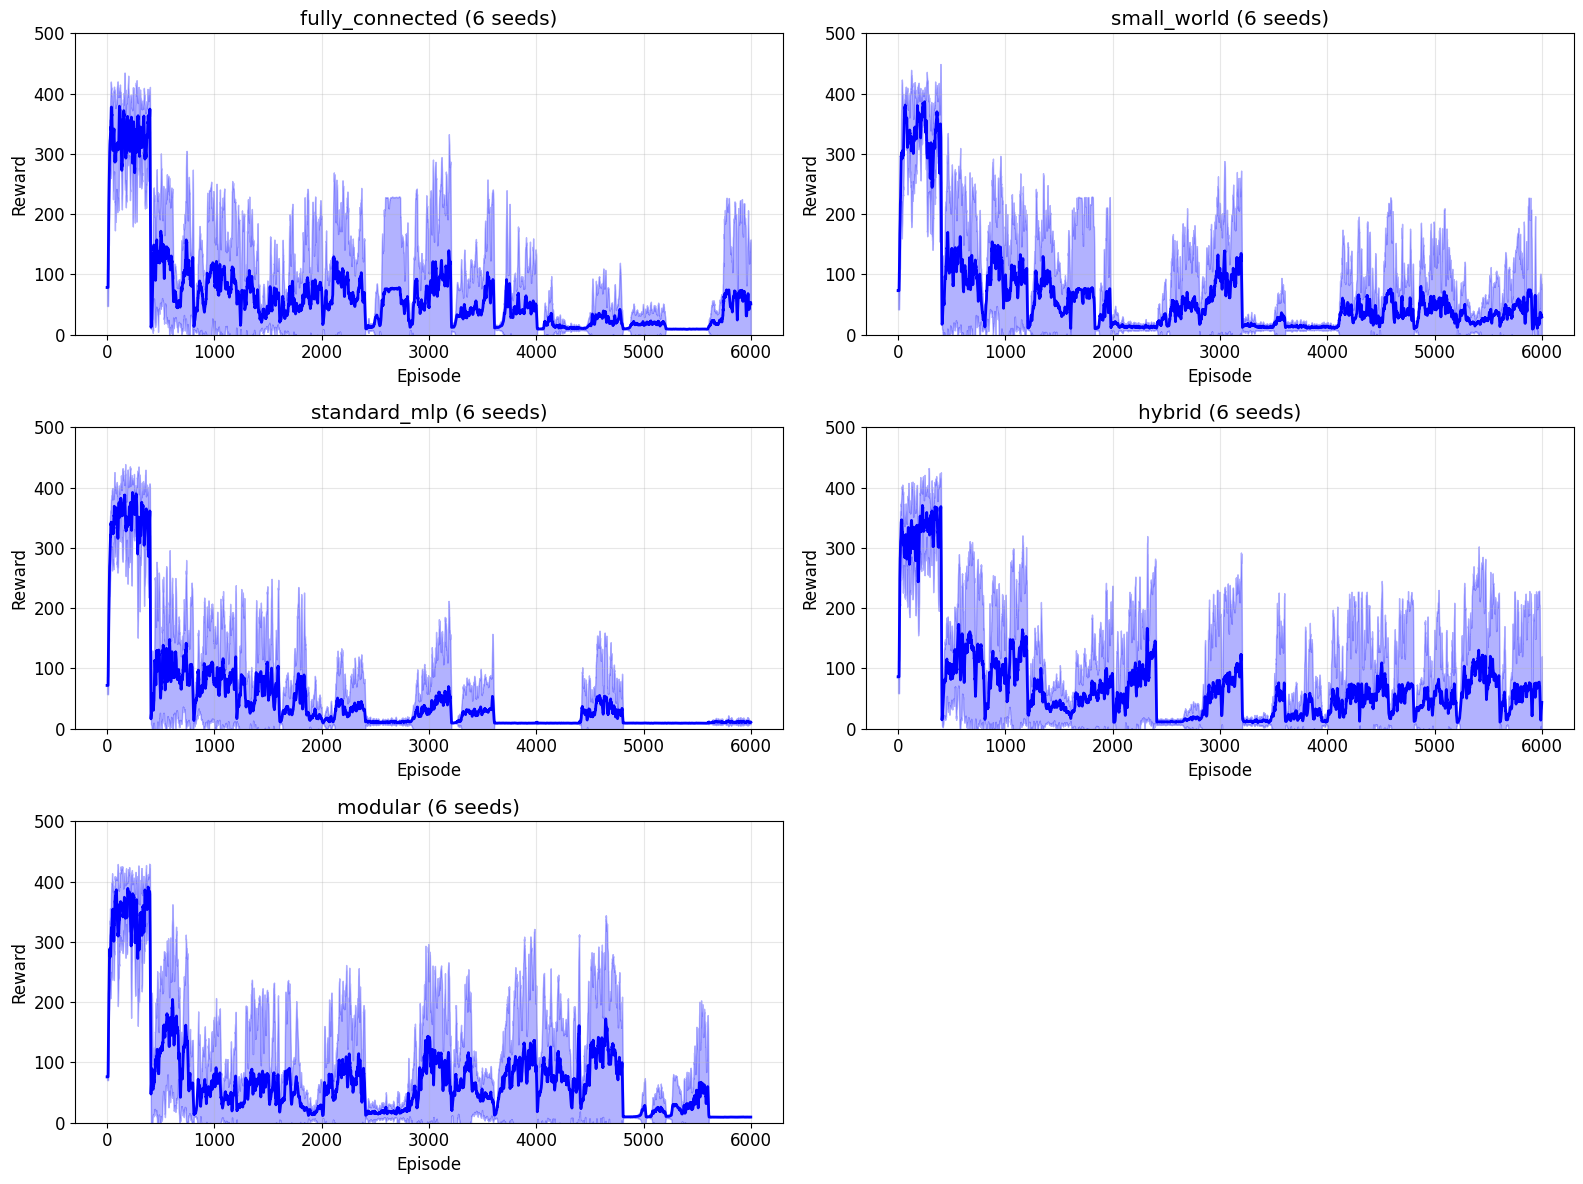

✅ Figure6 aggregation plots generated


In [47]:
def plot_figure6_aggregation(figure6_data: Dict):
    """
    Create Figure6-style plots with multi-seed aggregation and confidence intervals.
    """
    if not figure6_data:
        print("❌ No Figure6 data available")
        return
    
    # Create subplots
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    # Plot 1: All topologies together
    ax1 = axes[0]
    colors = plt.cm.Set3(np.linspace(0, 1, len(figure6_data)))
    
    for i, (topology_key, data) in enumerate(figure6_data.items()):
        episodes = data['episodes']
        mean_rewards = data['mean_rewards']
        lower_bound = data['lower_bound']
        upper_bound = data['upper_bound']
        
        # Plot mean line
        ax1.plot(episodes, mean_rewards, 
                label=f"{data['topology_type']} ({data['num_seeds']} seeds)", 
                color=colors[i], linewidth=2)
        
        # Plot confidence interval
        ax1.fill_between(episodes, lower_bound, upper_bound, 
                        alpha=0.3, color=colors[i])
    
    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Smoothed Episode Reward (window=5)')
    ax1.set_title('Multi-Seed Performance Comparison (All Topologies)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 500)  # Set y-axis limits to [0, 500]
    
    # Plot 2: Individual topology plots
    ax2 = axes[1]
    n_topologies = len(figure6_data)
    cols = 2
    rows = (n_topologies + 1) // 2
    
    # Create subplot grid
    fig2, axes2 = plt.subplots(rows, cols, figsize=(16, 4*rows))
    if rows == 1:
        axes2 = axes2.reshape(1, -1)
    
    for i, (topology_key, data) in enumerate(figure6_data.items()):
        row = i // cols
        col = i % cols
        ax = axes2[row, col]
        
        episodes = data['episodes']
        mean_rewards = data['mean_rewards']
        lower_bound = data['lower_bound']
        upper_bound = data['upper_bound']
        
        ax.plot(episodes, mean_rewards, linewidth=2, color='blue')
        ax.fill_between(episodes, lower_bound, upper_bound, alpha=0.3, color='blue')
        
        ax.set_xlabel('Episode')
        ax.set_ylabel('Reward')
        ax.set_title(f"{data['topology_type']} ({data['num_seeds']} seeds)")
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 500)  # Set y-axis limits to [0, 500]
    
    # Hide empty subplots
    for i in range(len(figure6_data), rows * cols):
        row = i // cols
        col = i % cols
        axes2[row, col].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Figure6 aggregation plots generated")

# Generate Figure6 plots
plot_figure6_aggregation(figure6_data)

## Section 2: Learning Speed Analysis (Option B)

Calculate and plot learning speed using sliding window derivatives of smoothed reward curves.

In [48]:
def calculate_learning_speed(figure6_data: Dict, derivative_window: int = 10) -> Dict:
    """
    Calculate learning speed using sliding window derivatives.
    
    Args:
        figure6_data: Data from Figure6 analysis
        derivative_window: Window size for derivative calculation
        
    Returns:
        Dictionary with learning speed data for each topology
    """
    learning_speed_data = {}
    
    for topology_key, data in figure6_data.items():
        episodes = data['episodes']
        mean_rewards = data['mean_rewards']
        
        if len(episodes) < derivative_window:
            continue
        
        # Calculate sliding window derivative
        learning_rates = []
        derivative_episodes = []
        
        for i in range(derivative_window, len(episodes)):
            # Calculate rate of change over the window
            window_start = i - derivative_window
            window_end = i
            
            reward_change = mean_rewards[window_end] - mean_rewards[window_start]
            episode_change = episodes[window_end] - episodes[window_start]
            
            if episode_change > 0:
                learning_rate = reward_change / episode_change
            else:
                learning_rate = 0
            
            learning_rates.append(learning_rate)
            derivative_episodes.append(episodes[i])
        
        learning_speed_data[topology_key] = {
            'episodes': derivative_episodes,
            'learning_rates': learning_rates,
            'topology_type': data['topology_type'],
            'task_name': data['task_name']
        }
    
    return learning_speed_data

# Calculate learning speed
print("🔄 Calculating learning speed...")
learning_speed_data = calculate_learning_speed(figure6_data)
print(f"✅ Calculated learning speed for {len(learning_speed_data)} topology types")

🔄 Calculating learning speed...
✅ Calculated learning speed for 5 topology types


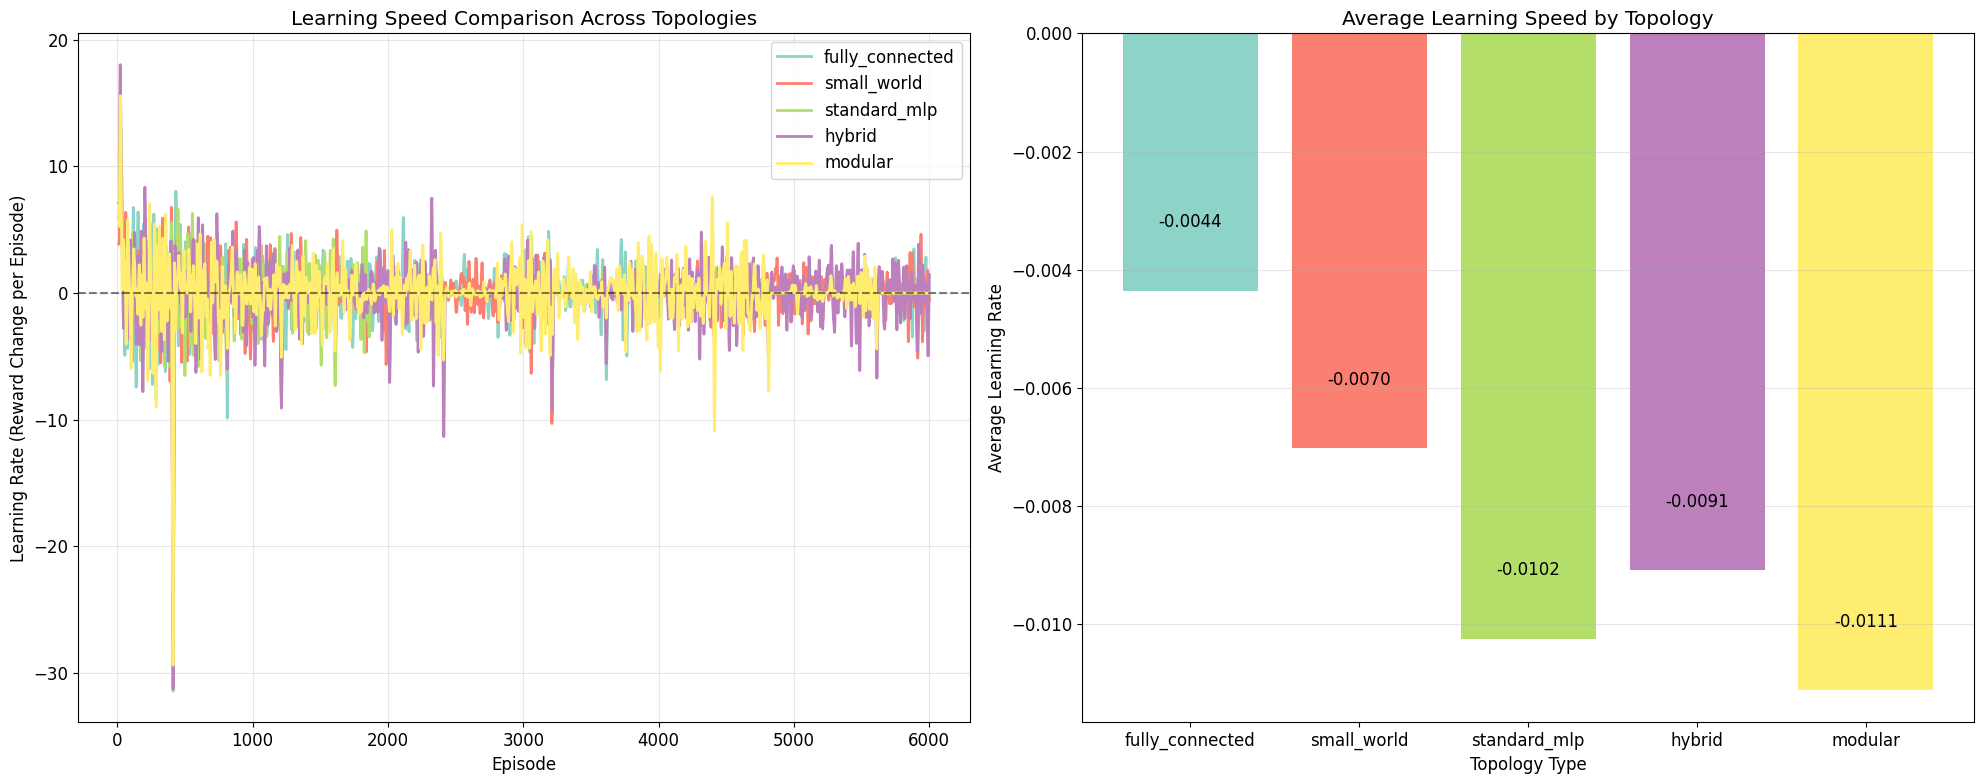

✅ Learning speed plots generated


In [49]:
def plot_learning_speed(learning_speed_data: Dict):
    """
    Plot learning speed comparison across topologies.
    """
    if not learning_speed_data:
        print("❌ No learning speed data available")
        return
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Plot 1: Learning rates over time
    colors = plt.cm.Set3(np.linspace(0, 1, len(learning_speed_data)))
    
    for i, (topology_key, data) in enumerate(learning_speed_data.items()):
        episodes = data['episodes']
        learning_rates = data['learning_rates']
        
        # Apply additional smoothing for better visualization
        smoothed_rates = apply_window_smoothing(learning_rates, window=5)
        
        ax1.plot(episodes, smoothed_rates, 
                label=f"{data['topology_type']}", 
                color=colors[i], linewidth=2)
    
    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Learning Rate (Reward Change per Episode)')
    ax1.set_title('Learning Speed Comparison Across Topologies')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    # Plot 2: Average learning rates
    topology_names = []
    avg_learning_rates = []
    
    for topology_key, data in learning_speed_data.items():
        topology_names.append(data['topology_type'])
        avg_rate = np.mean(data['learning_rates'])
        avg_learning_rates.append(avg_rate)
    
    bars = ax2.bar(topology_names, avg_learning_rates, color=colors[:len(topology_names)])
    ax2.set_xlabel('Topology Type')
    ax2.set_ylabel('Average Learning Rate')
    
    ax2.set_title('Average Learning Speed by Topology')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, rate in zip(bars, avg_learning_rates):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                f'{rate:.4f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Learning speed plots generated")

# Generate learning speed plots
plot_learning_speed(learning_speed_data)

## Section 3: Cumulative Reward Table

Calculate cumulative sums of mean episode rewards (averaged across seeds) and display as a comparison table.

In [50]:
def calculate_cumulative_rewards(figure6_data: Dict) -> pd.DataFrame:
    """
    Calculate cumulative rewards for each topology and create comparison table.
    """
    cumulative_data = []
    
    for topology_key, data in figure6_data.items():
        episodes = data['episodes']
        mean_rewards = data['mean_rewards']
        
        # Calculate cumulative sum
        cumulative_rewards = np.cumsum(mean_rewards)
        
        # Store key milestones
        milestones = [100, 500, 1000, 2000, 3000, 4000, 5000, 6000]
        milestone_data = {}
        
        for milestone in milestones:
            if milestone <= len(episodes):
                idx = milestone - 1  # Convert to 0-based index
                milestone_data[f'episode_{milestone}'] = cumulative_rewards[idx]
            else:
                milestone_data[f'episode_{milestone}'] = np.nan
        
        # Add final cumulative reward
        final_cumulative = cumulative_rewards[-1]
        
        row_data = {
            'Topology': data['topology_type'],
            'Task': data['task_name'],
            'Seeds': data['num_seeds'],
            'Total Episodes': len(episodes),
            'Final Cumulative Reward': final_cumulative,
            **milestone_data
        }
        
        cumulative_data.append(row_data)
    
    # Create DataFrame
    df = pd.DataFrame(cumulative_data)
    
    # Reorder columns for better readability
    base_cols = ['Topology', 'Task', 'Seeds', 'Total Episodes', 'Final Cumulative Reward']
    milestone_cols = [col for col in df.columns if col.startswith('episode_')]
    milestone_cols.sort(key=lambda x: int(x.split('_')[1]))
    
    df = df[base_cols + milestone_cols]
    
    return df

# Calculate cumulative rewards
print("�� Calculating cumulative rewards...")
cumulative_df = calculate_cumulative_rewards(figure6_data)
print("✅ Cumulative rewards calculated")

�� Calculating cumulative rewards...
✅ Cumulative rewards calculated


In [51]:
def display_cumulative_table(cumulative_df: pd.DataFrame):
    """
    Display cumulative reward comparison table.
    """
    if cumulative_df.empty:
        print("❌ No cumulative data available")
        return
    
    print("📊 Cumulative Reward Comparison Table")
    print("=" * 80)
    
    # Format the DataFrame for display
    display_df = cumulative_df.copy()
    
    # Format numeric columns
    numeric_cols = display_df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if col != 'Seeds' and col != 'Total Episodes':
            display_df[col] = display_df[col].round(2)
    
    # Display the table
    print(display_df.to_string(index=False))
    
    print("\n" + "=" * 80)
    print("📈 Key Insights:")
    
    # Find best performing topology
    if 'Final Cumulative Reward' in display_df.columns:
        best_topology = display_df.loc[display_df['Final Cumulative Reward'].idxmax()]
        print(f"🏆 Best Overall Performance: {best_topology['Topology']} "
              f"({best_topology['Final Cumulative Reward']:.2f} cumulative reward)")
    
    # Show topology rankings
    if 'Final Cumulative Reward' in display_df.columns:
        rankings = display_df.sort_values('Final Cumulative Reward', ascending=False)
        print("\n🏅 Topology Rankings (by Final Cumulative Reward):")
        for i, (_, row) in enumerate(rankings.iterrows()):
            print(f"   {i+1}. {row['Topology']}: {row['Final Cumulative Reward']:.2f}")
    
    print("\n✅ Cumulative reward analysis complete")

# Display cumulative reward table
display_cumulative_table(cumulative_df)

📊 Cumulative Reward Comparison Table
       Topology        Task  Seeds  Total Episodes  Final Cumulative Reward  episode_100  episode_500  episode_1000  episode_2000  episode_3000  episode_4000  episode_5000  episode_6000
fully_connected CartPole-v1      6            6000                403134.18     28327.52    138802.52     184028.63     247756.05     306482.10     359535.98     377468.38     403134.18
    small_world CartPole-v1      6            6000                389822.70     28006.80    137452.48     187519.23     251306.15     284646.88     316784.43     354130.65     389822.70
   standard_mlp CartPole-v1      6            6000                315668.63     28943.07    143209.27     187544.67     243225.20     263930.32     287120.35     305660.38     315668.63
         hybrid CartPole-v1      6            6000                449295.92     27940.03    135505.80     188627.32     252957.48     299719.07     335930.98     386359.93     449295.92
        modular CartPole-v1      

In [66]:
# Import additional libraries for statistical analysis
from scipy import stats
from scipy.stats import f_oneway, tukey_hsd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("✅ Statistical analysis libraries imported")

✅ Statistical analysis libraries imported


In [67]:
# ============================================================================
# CORRECTED STATISTICAL ANALYSIS - USING CUMULATIVE REWARDS
# ============================================================================

def calculate_cumulative_variance_components(topology_groups: Dict) -> Dict:
    """
    Calculate within-topology and between-topology variance components using CUMULATIVE REWARDS.
    
    Returns:
        Dictionary with variance statistics for each topology and overall
    """
    topology_stats = {}
    all_cumulative_rewards = []
    topology_means = []
    
    for topology_key, group in topology_groups.items():
        cumulative_rewards = []
        for run in group['runs']:
            episode_data = run['episode_data']
            # Calculate cumulative reward (sum of all episode rewards)
            cumulative_reward = episode_data['episode_return_raw'].sum()
            cumulative_rewards.append(cumulative_reward)
            all_cumulative_rewards.append(cumulative_reward)
        
        if cumulative_rewards:
            mean_reward = np.mean(cumulative_rewards)
            var_within = np.var(cumulative_rewards, ddof=1)  # Within-topology variance
            std_within = np.std(cumulative_rewards, ddof=1)
            cv_within = std_within / mean_reward if mean_reward > 0 else 0
            
            topology_stats[group['topology_type']] = {
                'mean': mean_reward,
                'variance_within': var_within,
                'std_within': std_within,
                'cv_within': cv_within,
                'n_seeds': len(cumulative_rewards),
                'cumulative_rewards': cumulative_rewards
            }
            
            topology_means.append(mean_reward)
    
    # Between-topology variance
    overall_mean = np.mean(all_cumulative_rewards)
    var_between = np.var(topology_means, ddof=1) if len(topology_means) > 1 else 0
    var_total = np.var(all_cumulative_rewards, ddof=1)
    
    return {
        'topology_stats': topology_stats,
        'overall_stats': {
            'overall_mean': overall_mean,
            'variance_between': var_between,
            'variance_total': var_total,
            'n_topologies': len(topology_means),
            'n_total_seeds': len(all_cumulative_rewards)
        }
    }

def test_cumulative_topology_significance(topology_groups: Dict) -> Tuple:
    """
    Test statistical significance between topologies using CUMULATIVE REWARDS.
    
    Returns:
        Tuple of (DataFrame with test results, F-statistic, ANOVA p-value)
    """
    # Prepare data for ANOVA
    topology_data = {}
    for topology_key, group in topology_groups.items():
        cumulative_rewards = []
        for run in group['runs']:
            episode_data = run['episode_data']
            cumulative_reward = episode_data['episode_return_raw'].sum()
            cumulative_rewards.append(cumulative_reward)
        
        if cumulative_rewards:
            topology_data[group['topology_type']] = cumulative_rewards
    
    # One-way ANOVA
    topology_names = list(topology_data.keys())
    topology_arrays = list(topology_data.values())
    
    f_stat, p_value = f_oneway(*topology_arrays)
    
    # Post-hoc Tukey HSD test
    tukey_result = tukey_hsd(*topology_arrays)
    
    # Create results table
    results = []
    for i, topology1 in enumerate(topology_names):
        for j, topology2 in enumerate(topology_names):
            if i < j:  # Only upper triangle
                p_val = tukey_result.pvalue[i, j]
                significant = p_val < 0.05
                
                results.append({
                    'Topology_1': topology1,
                    'Topology_2': topology2,
                    'p_value': p_val,
                    'significant': significant,
                    'effect_size': 'Large' if p_val < 0.001 else 'Medium' if p_val < 0.01 else 'Small' if p_val < 0.05 else 'None'
                })
    
    return pd.DataFrame(results), f_stat, p_value

print("✅ Corrected statistical analysis functions defined")

✅ Corrected statistical analysis functions defined


In [ ]:
def create_cumulative_variance_summary_table(variance_components: Dict, significance_results: Tuple) -> pd.DataFrame:
    """
    Create a comprehensive summary table with variance and significance statistics using CUMULATIVE REWARDS.
    """
    topology_stats = variance_components['topology_stats']
    overall_stats = variance_components['overall_stats']
    significance_df, f_stat, anova_p = significance_results
    
    # Create summary table
    summary_data = []
    for topology, stats in topology_stats.items():
        # Count significant comparisons for this topology
        sig_comparisons = len(significance_df[
            (significance_df['Topology_1'] == topology) | 
            (significance_df['Topology_2'] == topology)
        ][significance_df['significant'] == True])
        
        total_comparisons = len(significance_df[
            (significance_df['Topology_1'] == topology) | 
            (significance_df['Topology_2'] == topology)
        ])
        
        summary_data.append({
            'Topology': topology,
            'Mean_Cumulative_Reward': stats['mean'],
            'Variance_Within': stats['variance_within'],
            'Std_Within': stats['std_within'],
            'CV_Within': stats['cv_within'],
            'N_Seeds': stats['n_seeds'],
            'Significant_Comparisons': f"{sig_comparisons}/{total_comparisons}",
            'Significance_Rate': f"{sig_comparisons/total_comparisons*100:.1f}%" if total_comparisons > 0 else "0%"
        })
    
    summary_df = pd.DataFrame(summary_data)
    
    # Add overall statistics
    summary_df.loc['OVERALL'] = {
        'Topology': 'OVERALL',
        'Mean_Cumulative_Reward': overall_stats['overall_mean'],
        'Variance_Within': 'N/A',
        'Std_Within': 'N/A', 
        'CV_Within': 'N/A',
        'N_Seeds': overall_stats['n_total_seeds'],
        'Significant_Comparisons': f"ANOVA: F={f_stat:.3f}, p={anova_p:.6f}",
        'Significance_Rate': 'Significant' if anova_p < 0.05 else 'Not Significant'
    }
    
    return summary_df

print("✅ Corrected summary table function defined")

✅ Corrected summary table function defined


In [ ]:
def plot_cumulative_variance_decomposition(variance_components: Dict):
    """
    Visualize within-topology vs between-topology variance using CUMULATIVE REWARDS.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    topology_stats = variance_components['topology_stats']
    
    # Plot 1: Within-topology variance (coefficient of variation)
    topologies = list(topology_stats.keys())
    cv_values = [stats['cv_within'] for stats in topology_stats.values()]
    
    bars1 = ax1.bar(topologies, cv_values, color='skyblue', alpha=0.7)
    ax1.set_ylabel('Coefficient of Variation (Within-Topology)')
    ax1.set_title('Consistency Within Each Topology (Cumulative Rewards)')
    ax1.tick_params(axis='x', rotation=45)
    
    # Add value labels
    for bar, cv in zip(bars1, cv_values):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                f'{cv:.3f}', ha='center', va='bottom')
    
    # Plot 2: Between-topology comparison
    means = [stats['mean'] for stats in topology_stats.values()]
    stds = [stats['std_within'] for stats in topology_stats.values()]
    
    bars2 = ax2.bar(topologies, means, yerr=stds, capsize=5, 
                   color='lightcoral', alpha=0.7, error_kw={'linewidth': 2})
    ax2.set_ylabel('Mean Cumulative Reward ± Std')
    ax2.set_title('Performance Comparison Between Topologies (Cumulative Rewards)')
    ax2.tick_params(axis='x', rotation=45)
    
    # Format y-axis to show values in thousands
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))
    
    plt.tight_layout()
    plt.show()

def perform_cumulative_pca_analysis(topology_groups: Dict):
    """
    Perform PCA analysis on cumulative rewards to identify topology clusters.
    """
    # Prepare data: cumulative rewards for each seed
    cumulative_rewards = []
    topology_labels = []
    seed_labels = []
    
    for topology_key, group in topology_groups.items():
        for run in group['runs']:
            episode_data = run['episode_data']
            cumulative_reward = episode_data['episode_return_raw'].sum()
            
            cumulative_rewards.append([cumulative_reward])  # Single feature
            topology_labels.append(group['topology_type'])
            seed_labels.append(f"{group['topology_type']}_seed{run['seed']}")
    
    if len(cumulative_rewards) < 2:
        print("❌ Not enough data for PCA analysis")
        return
    
    # Standardize the data
    scaler = StandardScaler()
    cumulative_rewards_scaled = scaler.fit_transform(cumulative_rewards)
    
    # Perform PCA
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(cumulative_rewards_scaled)
    
    # Create PCA plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: PCA scatter plot colored by topology
    unique_topologies = list(set(topology_labels))
    colors = plt.cm.Set3(np.linspace(0, 1, len(unique_topologies)))
    
    for i, topology in enumerate(unique_topologies):
        mask = [label == topology for label in topology_labels]
        ax1.scatter(pca_result[mask, 0], pca_result[mask, 1], 
                   c=[colors[i]], label=topology, alpha=0.7, s=50)
    
    ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
    ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
    ax1.set_title('PCA: Topology Clustering in Cumulative Reward Space')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Explained variance
    ax2.bar(range(1, min(10, len(pca.explained_variance_ratio_)) + 1), 
           pca.explained_variance_ratio_[:10])
    ax2.set_xlabel('Principal Component')
    ax2.set_ylabel('Explained Variance Ratio')
    ax2.set_title('PCA Explained Variance (Cumulative Rewards)')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"✅ PCA Analysis Complete (Cumulative Rewards)")
    print(f"   PC1 explains {pca.explained_variance_ratio_[0]:.1%} of variance")
    print(f"   PC2 explains {pca.explained_variance_ratio_[1]:.1%} of variance")
    print(f"   Total explained by first 2 components: {sum(pca.explained_variance_ratio_[:2]):.1%}")

print("✅ Corrected visualization functions defined")

✅ Corrected visualization functions defined


In [68]:
# ============================================================================
# EXECUTE CORRECTED STATISTICAL ANALYSIS (CUMULATIVE REWARDS)
# ============================================================================

print("🔄 Running CORRECTED Statistical Analysis (Cumulative Rewards)...")
print("=" * 70)

# 1. Calculate variance components using cumulative rewards
print("\n1. Calculating variance components (cumulative rewards)...")
cumulative_variance_components = calculate_cumulative_variance_components(topology_groups)

# 2. Test significance using cumulative rewards
print("2. Testing statistical significance (cumulative rewards)...")
cumulative_significance_results = test_cumulative_topology_significance(topology_groups)
cumulative_significance_df, f_stat, anova_p = cumulative_significance_results

# 3. Create summary table
print("3. Creating summary table (cumulative rewards)...")
cumulative_summary_table = create_cumulative_variance_summary_table(cumulative_variance_components, cumulative_significance_results)

# 4. Display results
print("\n�� CORRECTED VARIANCE & SIGNIFICANCE SUMMARY TABLE")
print("=" * 90)
print(cumulative_summary_table.to_string(index=False))

print("\n�� CORRECTED PAIRWISE SIGNIFICANCE TESTS")
print("=" * 70)
print(cumulative_significance_df.to_string(index=False))

print("\n📈 CORRECTED OVERALL ANOVA RESULTS")
print("=" * 50)
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {anova_p:.6f}")
print(f"Result: {'Significant difference between topologies' if anova_p < 0.05 else 'No significant difference between topologies'}")

print("\n✅ CORRECTED Statistical analysis complete!")

🔄 Running CORRECTED Statistical Analysis (Cumulative Rewards)...

1. Calculating variance components (cumulative rewards)...
2. Testing statistical significance (cumulative rewards)...
3. Creating summary table (cumulative rewards)...

�� CORRECTED VARIANCE & SIGNIFICANCE SUMMARY TABLE
       Topology  Mean_Cumulative_Reward     Variance_Within     Std_Within CV_Within  N_Seeds    Significant_Comparisons Significance_Rate
fully_connected           402846.500000  28407748180.299999  168545.982391  0.418388        6                        0/4              0.0%
    small_world           389511.000000        5245211842.4   72423.834767  0.185935        6                        0/4              0.0%
   standard_mlp           315267.500000        4170037104.3   64575.824457  0.204829        6                        0/4              0.0%
         hybrid           448922.833333  33820508158.966667   183903.52949  0.409655        6                        0/4              0.0%
        modular   